<a href="https://colab.research.google.com/github/Cado87/Fruit-project/blob/main/Detection/YOLO%20/Dataset_analysis_roboflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="h4cT0fR7NYJQWUIdF1pd")
project = rf.workspace("fruitsdetection").project("fruits-by-yolo")
version = project.version(1)
dataset = version.download("coco")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 84.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fruits-by-YOLO-1 in coco:: 100%|██████████| 2982/2982 [00:00<00:00, 3947.60it/s]


Counting classes in train set...
Counting classes in valid set...
Counting classes in test set...

Class Distribution:
- Orange: 990
- Watermelon: 890
- Sugerapple: 828
- Kiwi: 815
- Mango: 762
- Banana: 637
- Apple: 547
- Grapes: 527
- Pineapple: 366


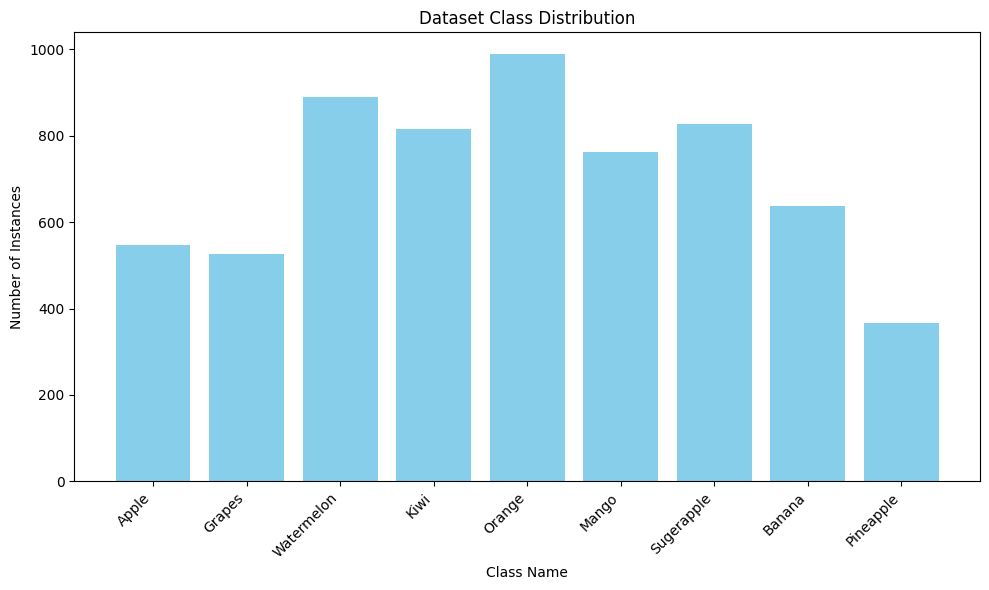

In [6]:
from collections import Counter
import matplotlib.pyplot as plt
import json
import os # Needed to join paths

class_counts = Counter()

# Explicitly set the dataset path based on Roboflow's typical download location
# and the project name, as the 'dataset' variable appears to be an object.
dataset_path = os.path.join(os.getcwd(), "Fruits-by-YOLO-1")

def count_classes_in_split(split_name, counts_dict):
    annotations_file = os.path.join(dataset_path, split_name, "_annotations.coco.json")

    if not os.path.exists(annotations_file):
        print(f"Warning: Annotation file not found for {split_name} at {annotations_file}")
        return

    with open(annotations_file, 'r') as f:
        coco_data = json.load(f)

    # Create a mapping from category ID (as in COCO JSON) to category name
    # This is more robust as COCO category IDs might not be contiguous or start from 0
    category_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}

    for annotation in coco_data['annotations']:
        class_id = annotation['category_id']
        class_name = category_id_to_name.get(class_id, f"Unknown Class ID {class_id}")
        counts_dict[class_name] += 1

print("Counting classes in train set...")
count_classes_in_split("train", class_counts)
print("Counting classes in valid set...")
count_classes_in_split("valid", class_counts)
print("Counting classes in test set...")
count_classes_in_split("test", class_counts)


print("\nClass Distribution:")
for class_name, count in class_counts.most_common():
    print(f"- {class_name}: {count}")

# Optional: Visualize the class distribution
if class_counts:
    labels = list(class_counts.keys())
    sizes = list(class_counts.values())

    plt.figure(figsize=(10, 6))
    plt.bar(labels, sizes, color='skyblue')
    plt.xlabel('Class Name')
    plt.ylabel('Number of Instances')
    plt.title('Dataset Class Distribution')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No classes found in the dataset.")